<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2025-12-02 06:29:27--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.2’

survey-data.csv.2   100%[===================>] 152.13M  54.7MB/s    in 2.8s    

2025-12-02 06:29:32 (54.7 MB/s) - ‘survey-data.csv.2’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 34.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 36.2 MB/s eta 0:00:00


Matplotlib is building the font cache; this may take a moment.


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


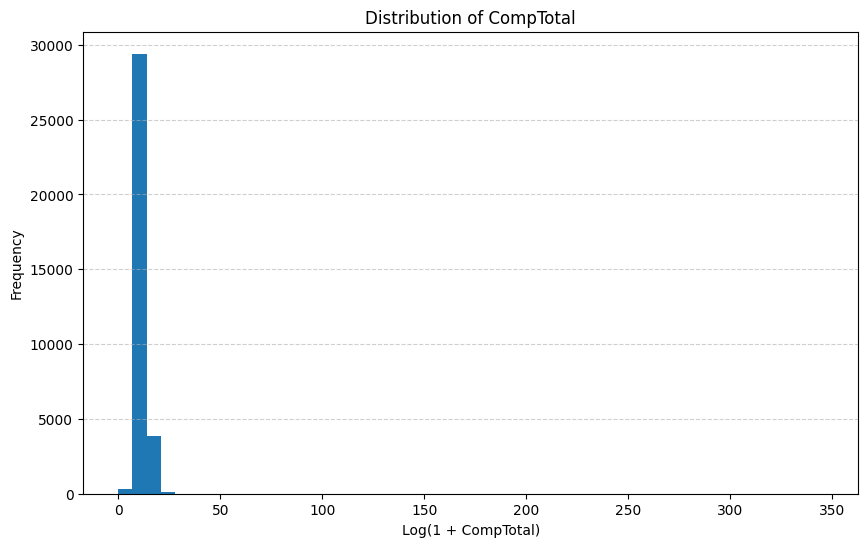

In [6]:
## Write your code here
import numpy as np

QUERY = """
SELECT CompTotal
FROM main
"""
df_comp = pd.read_sql_query(QUERY, conn)

df_comp = df_comp.dropna()
df_comp.head()

plt.figure(figsize = (10,6))

plt.hist(
    np.log1p(df_comp['CompTotal']),
    bins = 50
)

plt.title('Distribution of CompTotal')
plt.xlabel('Log(1 + CompTotal)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

(array([3.3739e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([0.e+000, 1.e+149, 2.e+149, 3.e+149, 4.e+149, 5.e+149, 6.e+149,
        7.e+149, 8.e+149, 9.e+149, 1.e+150]),
 <BarContainer object of 10 artists>)

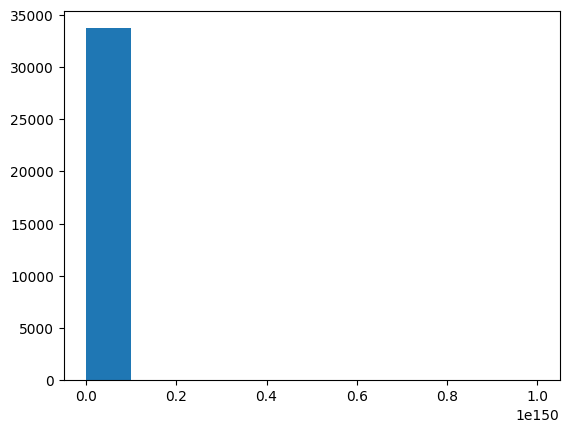

In [16]:
import numpy as np

plt.hist(df['CompTotal'])


**Box Plots**

Plot a box plot of Age.


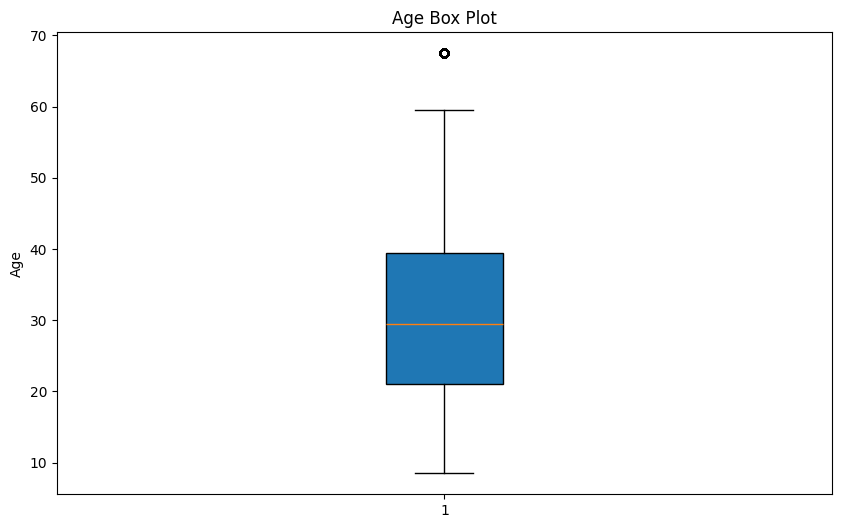

In [48]:
## Write your code here
QUERY1 = """
SELECT Age
From main
"""
df_age = pd.read_sql_query(QUERY1, conn)

age_midpoint_map = {
    'Under 18 years old' : 8.5,
    '18-24 years old' : 21.0,
    '25-34 years old' : 29.5,
    '35-44 years old' : 39.5,
    '45-54 years old' : 49.5,
    '55-64 years old' : 59.5,
    '65 years or older' : 67.5,
}

df_age['Age_Midpoint'] = df_age.replace(age_midpoint_map)
df_age['Age_Midpoint'] = pd.to_numeric(df_age['Age_Midpoint'], errors = 'coerce')

imputation_mean = df_age['Age_Midpoint'].mean()

df_age['Age_Midpoint'] = df_age['Age_Midpoint'].replace('Prefer not to say', imputation_mean)


plt.figure(figsize = (10,6))
plt.boxplot(
    df_age['Age_Midpoint'].dropna(), # Pass the clean numerical data
    patch_artist=True # Allows coloring of the box
)
plt.title('Age Box Plot')
plt.ylabel('Age')
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


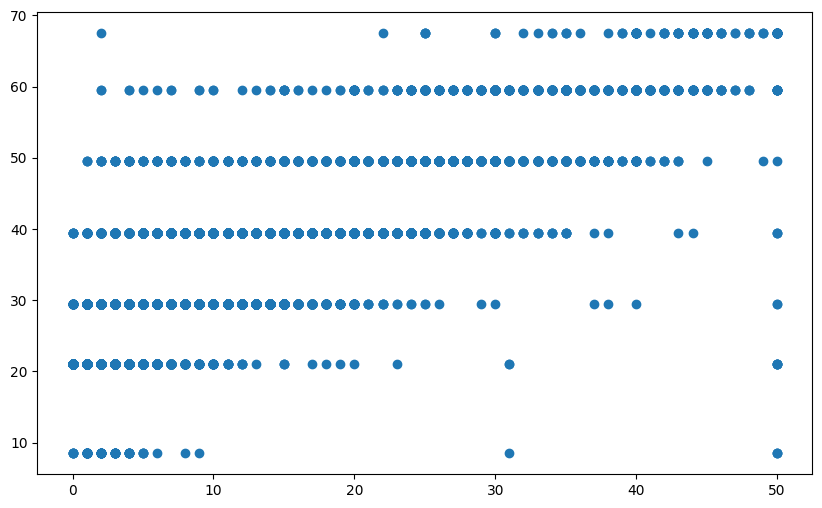

In [20]:
## Write your code here
QUERY = """
SELECT WorkExp, Age
From main
"""

df_combined = pd.read_sql_query(QUERY, conn)


age_midpoint_map = {
    'Under 18 years old' : 8.5,
    '18-24 years old' : 21.0,
    '25-34 years old' : 29.5,
    '35-44 years old' : 39.5,
    '45-54 years old' : 49.5,
    '55-64 years old' : 59.5,
    '65 years or older' : 67.5,
}

df_combined['Age_Midpoint'] = df_combined['Age'].replace(age_midpoint_map)
df_combined['Age_Midpoint'] = pd.to_numeric(df_combined['Age_Midpoint'], errors = 'coerce')

imputation_mean = df_combined['Age_Midpoint'].mean()

df_combined['Age_Midpoint'] = df_combined['Age_Midpoint'].replace('Prefer not to say', imputation_mean)

plot_data = df_combined.dropna(subset=['WorkExp', 'Age_Midpoint'])

plt.figure(figsize = (10,6))
plt.scatter(
    x = plot_data['WorkExp'],
    y = plot_data['Age_Midpoint']
)


**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


/tmp/ipykernel_299/3985491605.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_combined['Age_Midpoint'] = df_combined['Age'].replace(age_midpoint_map)


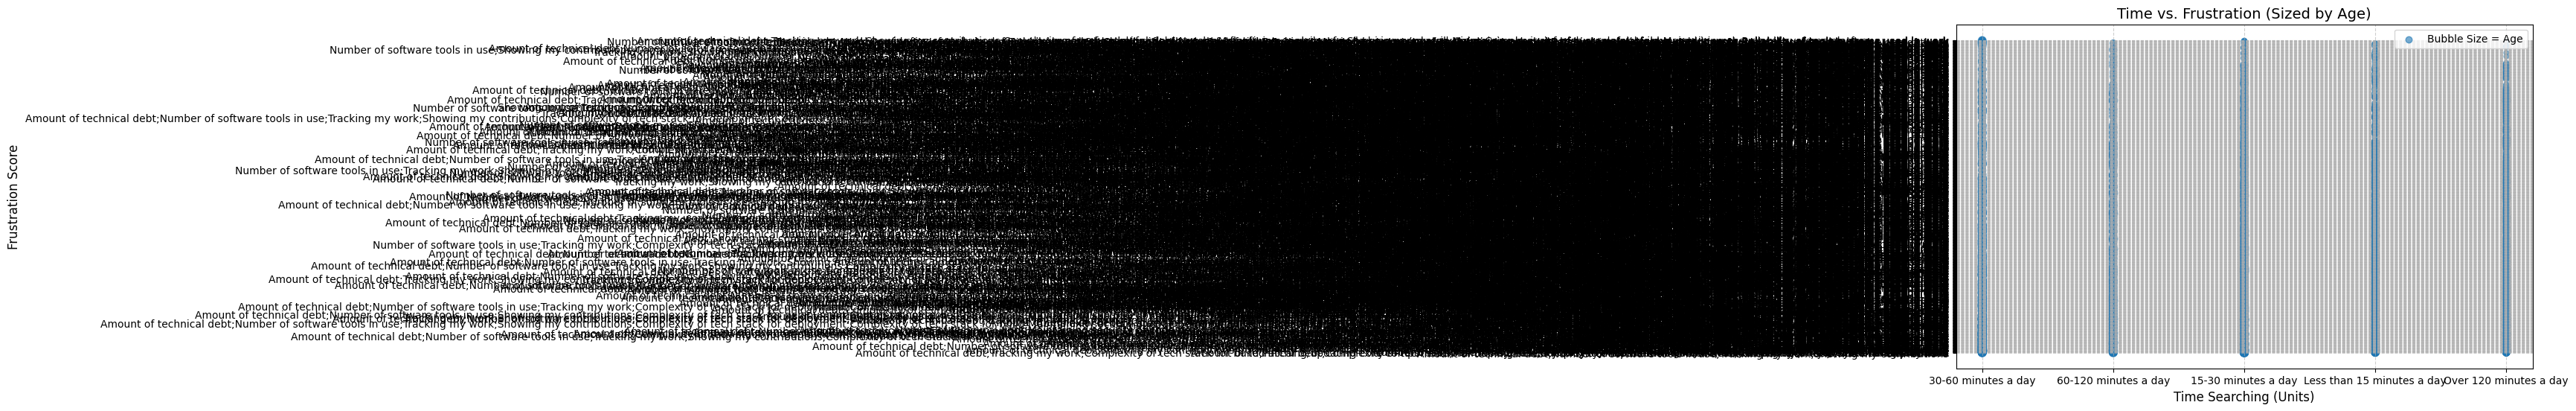

In [25]:
QUERY = """
SELECT WorkExp, Age, TimeSearching, Frustration
FROM main
"""
df_combined = pd.read_sql_query(QUERY, conn)

age_midpoint_map = {
    'Under 18 years old' : 8.5,
    '18-24 years old' : 21.0,
    '25-34 years old' : 29.5,
    '35-44 years old' : 39.5,
    '45-54 years old' : 49.5,
    '55-64 years old' : 59.5,
    '65 years or older' : 67.5,
    # Replace the 'Prefer not to say' string with NaN immediately
    'Prefer not to say': np.nan 
}

# --- 1. Clean Age Midpoint Column ---
df_combined['Age_Midpoint'] = df_combined['Age'].replace(age_midpoint_map)

# Convert to numeric. This turns any other non-mapped strings/junk into NaN.
df_combined['Age_Midpoint'] = pd.to_numeric(df_combined['Age_Midpoint'], errors='coerce')

# Calculate imputation mean from valid data
imputation_mean = df_combined['Age_Midpoint'].mean()

# Fill all NaNs (both original and coerced) with the calculated mean
df_combined['Age_Midpoint'] = df_combined['Age_Midpoint'].fillna(imputation_mean)

# --- 2. Create Synchronized Plot Data ---
# Select all necessary columns and drop rows where any of the three are missing.
# We assume 'TimeSearching' and 'Frustration' are also columns in df_combined.
plot_data = df_combined.dropna(subset=['TimeSearching', 'Frustration', 'Age_Midpoint']).copy()

# Optional: Convert to int (use round to preserve accuracy)
plot_data['Age_Midpoint'] = plot_data['Age_Midpoint'].round(0).astype(int)


# --- 3. Plot Correctly ---
plt.figure(figsize = (10,6))
plt.scatter(
    x = plot_data['TimeSearching'], # X from the synchronized data
    y = plot_data['Frustration'],   # Y from the synchronized data
    s = plot_data['Age_Midpoint'],  # S from the synchronized data
    alpha = 0.6,
    label = 'Bubble Size = Age'
)

plt.title('Time vs. Frustration (Sized by Age)', fontsize=14)
plt.xlabel('Time Searching (Units)', fontsize=12)
plt.ylabel('Frustration Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


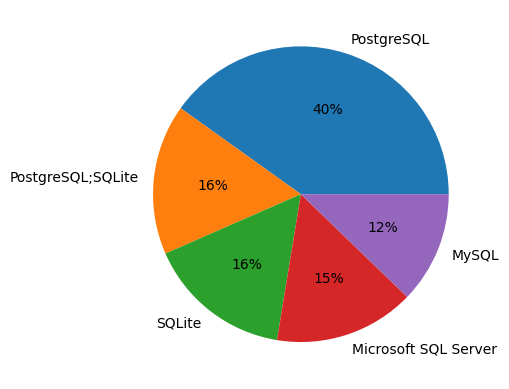

In [33]:
## Write your code here
top_5 = df['DatabaseWantToWorkWith'].value_counts().head()
top_5

plt.pie(top_5.values, labels = top_5.index, autopct='%1.0f%%');

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


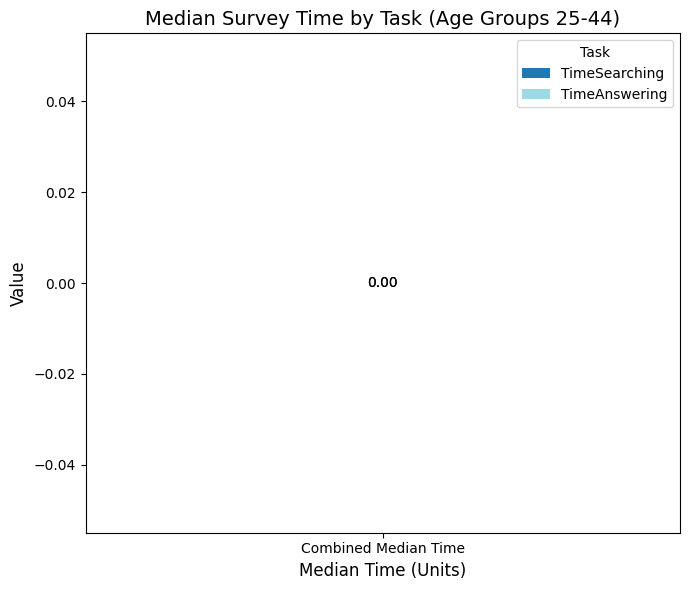

Stacked bar chart generated successfully after converting time columns to numeric.

Median Times (Units):
TimeSearching   NaN
TimeAnswering   NaN
dtype: float64


In [7]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

TIME_SEARCHING_COL = 'TimeSearching'
TIME_ANSWERING_COL = 'TimeAnswering'
AGE_COL = 'Age'
target_age_groups = ['25-34 years old', '35-44 years old']

# --- 1. Filter Data by Age Group ---
df_filtered = df[df[AGE_COL].isin(target_age_groups)].copy()

# --- CRITICAL FIX: Convert Time Columns to Numeric ---
df_filtered[TIME_SEARCHING_COL] = pd.to_numeric(df_filtered[TIME_SEARCHING_COL], errors='coerce')
df_filtered[TIME_ANSWERING_COL] = pd.to_numeric(df_filtered[TIME_ANSWERING_COL], errors='coerce')


# --- 2. Calculate Median Times for the Filtered Group ---
# This now works because the columns are numeric (float)
median_times = df_filtered[[TIME_SEARCHING_COL, TIME_ANSWERING_COL]].median()


# --- 3. Prepare Data for Stacked Bar Plot ---
plot_data_stacked = median_times.to_frame().T
plot_data_stacked.index = ['Median Time']


# --- 4. Create Stacked Bar Chart ---
plt.figure(figsize=(7, 6))

plot_data_stacked.plot(
    kind='bar', 
    stacked=True, 
    ax=plt.gca(),
    colormap='tab20'
)

# Add Labels and Title
plt.title(f'Median Survey Time by Task (Age Groups 25-44)', fontsize=14)
plt.xlabel('Median Time (Units)', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=0, ticks=[0], labels=['Combined Median Time'])
plt.legend(title='Task', loc='upper right')

# Add values to the stacked bars for readability
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        width = bar.get_width()
        x = bar.get_x()
        
        plt.gca().text(
            x + width / 2., 
            bar.get_y() + height / 2., 
            f'{height:.2f}', 
            ha='center', 
            va='center', 
            color='black', 
            fontsize=10
        )

plt.tight_layout()
plt.show()

print("Stacked bar chart generated successfully after converting time columns to numeric.")
print(f"\nMedian Times (Units):")
print(median_times)

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


In [15]:
## Write your code here

QUERY = """
SELECT Age, CompTotal
From main
"""

df_combined = pd.read_sql_query(QUERY, conn)


age_midpoint_map = {
    'Under 18 years old' : 8.5,
    '18-24 years old' : 21.0,
    '25-34 years old' : 29.5,
    '35-44 years old' : 39.5,
    '45-54 years old' : 49.5,
    '55-64 years old' : 59.5,
    '65 years or older' : 67.5,
    # Replace the 'Prefer not to say' string with NaN immediately
    'Prefer not to say': np.nan 
}

# --- 1. Clean Age Midpoint Column ---
df_combined['Age_Midpoint'] = df_combined['Age'].replace(age_midpoint_map)

# Convert to numeric. This turns any other non-mapped strings/junk into NaN.
df_combined['Age_Midpoint'] = pd.to_numeric(df_combined['Age_Midpoint'], errors='coerce')

# Calculate imputation mean from valid data
imputation_mean = df_combined['Age_Midpoint'].mean()

# Fill all NaNs (both original and coerced) with the calculated mean
df_combined['Age_Midpoint'] = df_combined['Age_Midpoint'].fillna(imputation_mean)

df_combined['CompTotal'] = df_combined['CompTotal'].fillna(df_combined['CompTotal'].mean())
#pd.set_option('display.float_format', '{:,.2f}'.format)



df_combined['Age_Midpoint'].value_counts()

/tmp/ipykernel_301/1258254695.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_combined['Age_Midpoint'] = df_combined['Age'].replace(age_midpoint_map)


Age_Midpoint
29.50    23911
39.50    14942
21.00    14098
49.50     6249
59.50     2575
8.50      2568
67.50      772
32.68      322
Name: count, dtype: int64

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


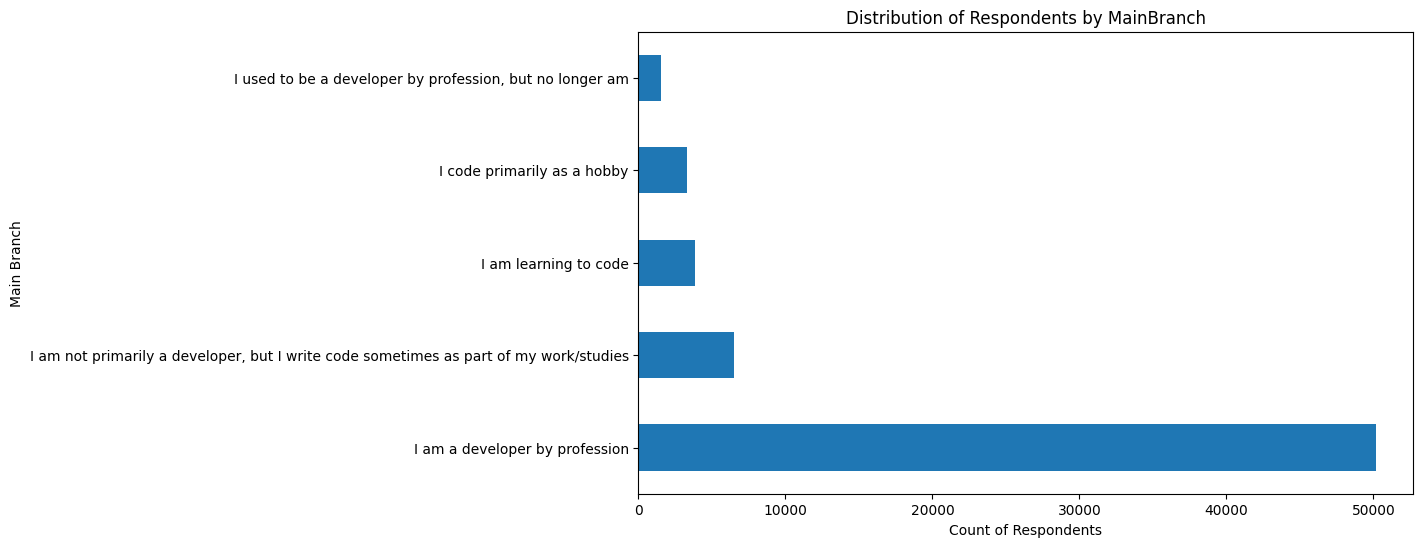

In [26]:
## Write your code here
main_branch_values = df['MainBranch'].value_counts()

plt.figure(figsize = (10,6))

main_branch_values.plot(kind = 'barh');
plt.title('Distribution of Respondents by MainBranch')
plt.xlabel('Count of Respondents')
plt.ylabel('Main Branch')
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
